# CME/CBOT Corn futures: a continuous nearby series

This demo uses the CME Group / CBOT Corn futures root ZC and shows how the
Barchart utilities turn individual contract histories into nearby lines.
It starts with deterministic offline data to explain the builder. The final
section fetches the actual Barchart histories by default.

In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next(
    (candidate for candidate in candidate_roots if (candidate / "Barchart").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Run this demo from a checkout containing the Barchart folder.")
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from Barchart import (
    BarchartFetcher,
    BarchartHistoricalData,
    ContinuousFuturesBuilder,
    expiry_key,
    parse_symbol,
)

START = "2024-01-02"
END = "2025-12-31"
CORN_ROOT = "ZC"
CORN_CYCLE = ["H", "K", "N", "U", "Z"]
# Set False for an offline-only run with no Barchart requests.
USE_LIVE_DATA = True

## 1. Build a deterministic offline illustration

The synthetic histories share a market path but have contract-level offsets
and noise. Each contract is only available during a plausible pre-expiry
window, making nearby selection and roll segments visible. These values are
illustrative and must not be interpreted as market prices.

In [2]:
def make_demo_contracts(start=START, end=END):
    dates = pd.bdate_range(start, end)
    rng = np.random.default_rng(2026)
    progress = np.arange(len(dates), dtype=float)
    market_shocks = rng.normal(0, 0.10, len(dates))
    market_path = (
        450
        + 0.035 * progress
        + 13 * np.sin(progress / 75)
        + np.cumsum(market_shocks)
    )

    symbols = [
        "ZCH24", "ZCK24", "ZCN24", "ZCU24", "ZCZ24",
        "ZCH25", "ZCK25", "ZCN25", "ZCU25", "ZCZ25", "ZCH26",
    ]
    contracts = {}
    for symbol in symbols:
        _, month, year, _ = parse_symbol(symbol)
        delivery_month = pd.Timestamp(year=year, month=month, day=1)
        active_start = delivery_month - pd.DateOffset(months=15)
        active_end = delivery_month - pd.DateOffset(months=1)
        mask = (dates >= active_start) & (dates <= active_end)
        contract_dates = dates[mask]
        positions = np.flatnonzero(mask)
        if len(contract_dates) == 0:
            continue

        contract_offset = 0.12 * (expiry_key(symbol) - expiry_key("ZCH24"))
        close = (
            market_path[positions]
            + contract_offset
            + rng.normal(0, 0.25, len(contract_dates))
        )
        contracts[symbol] = pd.DataFrame(
            {
                "date": contract_dates,
                "open": close - rng.uniform(0.2, 1.4, len(close)),
                "high": close + rng.uniform(0.5, 2.0, len(close)),
                "low": close - rng.uniform(0.5, 2.0, len(close)),
                "close": close,
                "volume": rng.integers(20_000, 160_000, len(close)),
                "openInterest": rng.integers(80_000, 500_000, len(close)),
            }
        )
    return contracts


contracts = make_demo_contracts()
display(
    pd.DataFrame(
        {
            "contract": list(contracts),
            "first_date": [frame["date"].min().date() for frame in contracts.values()],
            "last_date": [frame["date"].max().date() for frame in contracts.values()],
            "rows": [len(frame) for frame in contracts.values()],
        }
    )
)

,contract,first_date,last_date,rows
0,ZCH24,2024-01-02,2024-02-01,23
1,ZCK24,2024-01-02,2024-04-01,65
2,ZCN24,2024-01-02,2024-05-31,109
3,ZCU24,2024-01-02,2024-08-01,153
4,ZCZ24,2024-01-02,2024-11-01,219
5,ZCH25,2024-01-02,2025-01-31,284
6,ZCK25,2024-02-01,2025-04-01,304
7,ZCN25,2024-04-01,2025-05-30,305
8,ZCU25,2024-06-03,2025-08-01,305
9,ZCZ25,2024-09-02,2025-10-31,305


## 2. Select nearby lines and expose roll segments

In [3]:
builder = ContinuousFuturesBuilder(verbose=False)
nearby_1, segments_1 = builder.build(
    contracts,
    line_number=1,
    start=START,
    end=END,
    return_segments=True,
)
nearby_2, segments_2 = builder.build(
    contracts,
    line_number=2,
    start=START,
    end=END,
    return_segments=True,
)

display(
    pd.DataFrame(
        {
            "series": ["nearby 1", "nearby 2"],
            "rows": [len(nearby_1), len(nearby_2)],
            "contracts_used": [
                nearby_1["source_symbol"].nunique(),
                nearby_2["source_symbol"].nunique(),
            ],
            "rolls": [max(len(segments_1) - 1, 0), max(len(segments_2) - 1, 0)],
        }
    )
)
display(segments_1)

,series,rows,contracts_used,rolls
0,nearby 1,522,11,10
1,nearby 2,479,10,9


,segment_start,segment_end,line,source_symbol,n_rows
0,2024-01-02,2024-02-01,1,ZCH24,23
1,2024-02-02,2024-04-01,1,ZCK24,42
2,2024-04-02,2024-05-31,1,ZCN24,44
3,2024-06-03,2024-08-01,1,ZCU24,44
4,2024-08-02,2024-11-01,1,ZCZ24,66
5,2024-11-04,2025-01-31,1,ZCH25,65
6,2025-02-03,2025-04-01,1,ZCK25,42
7,2025-04-02,2025-05-30,1,ZCN25,43
8,2025-06-02,2025-08-01,1,ZCU25,45
9,2025-08-04,2025-10-31,1,ZCZ25,65


## 3. Plot the continuous series

Gold markers show where the selected source contract changes. The lower
panel compares the first and second nearby lines.

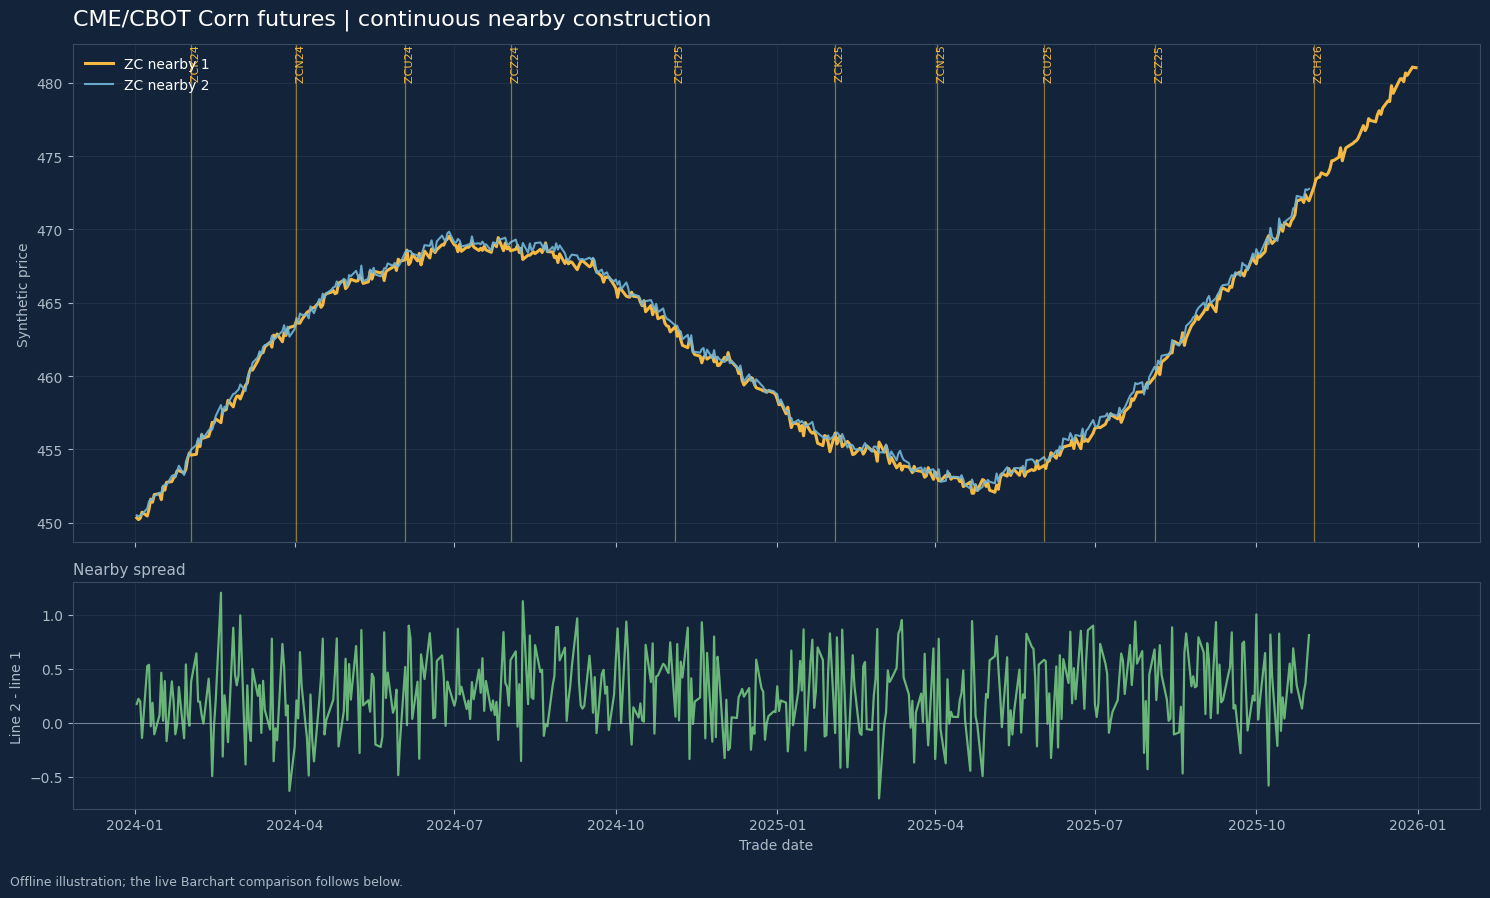

In [4]:
navy = "#13233A"
gold = "#F4B942"
field_green = "#69B578"
sky = "#73B7D8"
muted = "#AEB9C6"

plt.style.use("dark_background")
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]},
)
fig.patch.set_facecolor(navy)
for axis in axes:
    axis.set_facecolor(navy)
    axis.grid(True, color="#3A4A60", alpha=0.35)
    axis.tick_params(colors=muted)
    for spine in axis.spines.values():
        spine.set_color("#3A4A60")

axes[0].plot(
    nearby_1["date"],
    nearby_1["close"],
    color=gold,
    linewidth=2.2,
    label="ZC nearby 1",
)
axes[0].plot(
    nearby_2["date"],
    nearby_2["close"],
    color=sky,
    linewidth=1.5,
    alpha=0.9,
    label="ZC nearby 2",
)
for _, segment in segments_1.iloc[1:].iterrows():
    roll_date = pd.Timestamp(segment["segment_start"])
    axes[0].axvline(roll_date, color=gold, alpha=0.55, linewidth=0.9)
    axes[0].text(
        roll_date,
        axes[0].get_ylim()[1],
        f"  {segment['source_symbol']}",
        color=gold,
        rotation=90,
        va="top",
        ha="left",
        fontsize=8,
    )

axes[0].set_title(
    "CME/CBOT Corn futures | continuous nearby construction",
    loc="left",
    color="white",
    fontsize=16,
    pad=14,
)
axes[0].set_ylabel("Synthetic price", color=muted)
axes[0].legend(frameon=False, labelcolor="white", loc="upper left")

spread = nearby_2.set_index("date")["close"] - nearby_1.set_index("date")["close"]
axes[1].plot(spread.index, spread, color=field_green, linewidth=1.6)
axes[1].axhline(0, color=muted, linewidth=0.8, alpha=0.6)
axes[1].set_ylabel("Line 2 - line 1", color=muted)
axes[1].set_xlabel("Trade date", color=muted)
axes[1].set_title("Nearby spread", loc="left", color=muted, fontsize=11)

fig.text(
    0.01,
    0.01,
    "Offline illustration; the live Barchart comparison follows below.",
    color=muted,
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 4. Inspect one named contract: September 2026 Corn (ZCU26), offline illustration

CME/CBOT Corn uses the ZC root, U for September, and 26 for 2026. This
section keeps the individual contract history visible instead of selecting it
through a continuous nearby rule. The following chart is synthetic.

In [5]:
SPECIFIC_CONTRACT = "ZCU26"
SPECIFIC_START = "2025-01-02"
SPECIFIC_END = "2026-08-21"


def make_demo_contract_history(symbol, start, end, *, seed=2609):
    dates = pd.bdate_range(start, end)
    rng = np.random.default_rng(seed)
    progress = np.arange(len(dates), dtype=float)
    market_shocks = rng.normal(0, 0.10, len(dates))
    market_path = (
        465
        + 0.045 * progress
        + 12 * np.sin(progress / 80)
        + np.cumsum(market_shocks)
    )
    contract_offset = 0.15 * (expiry_key(symbol) - expiry_key("ZCH24"))
    close = (
        market_path
        + contract_offset
        + rng.normal(0, 0.22, len(dates))
    )
    return pd.DataFrame(
        {
            "date": dates,
            "open": close - rng.uniform(0.2, 1.2, len(close)),
            "high": close + rng.uniform(0.5, 1.8, len(close)),
            "low": close - rng.uniform(0.5, 1.8, len(close)),
            "close": close,
            "volume": rng.integers(25_000, 180_000, len(close)),
            "openInterest": rng.integers(90_000, 550_000, len(close)),
        }
    )


specific_contract = make_demo_contract_history(
    SPECIFIC_CONTRACT,
    SPECIFIC_START,
    SPECIFIC_END,
)
display(
    pd.DataFrame(
        {
            "contract": [SPECIFIC_CONTRACT],
            "contract_month": ["September 2026"],
            "first_date": [specific_contract["date"].min().date()],
            "last_date": [specific_contract["date"].max().date()],
            "rows": [len(specific_contract)],
            "last_close": [specific_contract["close"].iat[-1]],
            "average_volume": [specific_contract["volume"].mean()],
        }
    )
)

,contract,contract_month,first_date,last_date,rows,last_close,average_volume
0,ZCU26,September 2026,2025-01-02,2026-08-21,427,480.245003,104080.149883


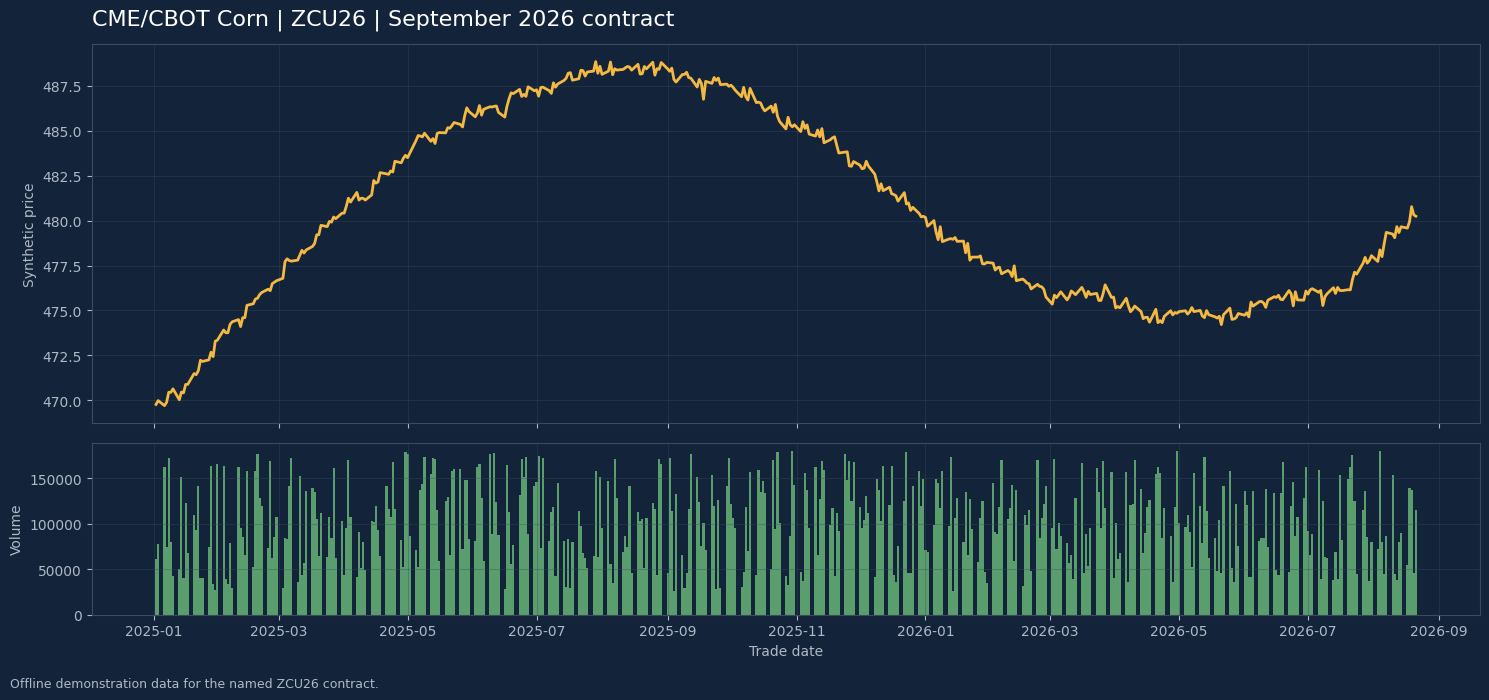

In [6]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]},
)
fig.patch.set_facecolor(navy)
for axis in axes:
    axis.set_facecolor(navy)
    axis.grid(True, color="#3A4A60", alpha=0.35)
    axis.tick_params(colors=muted)
    for spine in axis.spines.values():
        spine.set_color("#3A4A60")

axes[0].plot(
    specific_contract["date"],
    specific_contract["close"],
    color=gold,
    linewidth=2.0,
)
axes[0].set_title(
    "CME/CBOT Corn | ZCU26 | September 2026 contract",
    loc="left",
    color="white",
    fontsize=16,
    pad=14,
)
axes[0].set_ylabel("Synthetic price", color=muted)

axes[1].bar(
    specific_contract["date"],
    specific_contract["volume"],
    width=1.0,
    color=field_green,
    alpha=0.85,
)
axes[1].set_ylabel("Volume", color=muted)
axes[1].set_xlabel("Trade date", color=muted)
fig.text(
    0.01,
    0.01,
    "Offline demonstration data for the named ZCU26 contract.",
    color=muted,
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 5. Compare against the live Barchart history

This is the market-data comparison. It uses CME/CBOT Corn root ZC and the
default H/K/N/U/Z cycle, then fetches the full available history for the named
September 2026 contract (ZCU26). Barchart access and rate limits apply.

,segment_start,segment_end,line,source_symbol,n_rows
0,2024-01-02,2024-03-14,1,ZCH24,51
1,2024-03-15,2024-05-14,1,ZCK24,42
2,2024-05-15,2024-07-12,1,ZCN24,40
3,2024-07-15,2024-09-13,1,ZCU24,44
4,2024-09-16,2024-12-13,1,ZCZ24,64
5,2024-12-16,2025-03-14,1,ZCH25,61
6,2025-03-17,2025-05-14,1,ZCK25,42
7,2025-05-15,2025-07-14,1,ZCN25,40
8,2025-07-15,2025-09-12,1,ZCU25,43
9,2025-09-15,2025-12-12,1,ZCZ25,64


,contract,contract_month,first_date,last_date,rows,last_close,average_volume
0,ZCU26,September 2026,2023-12-14,2026-08-21,674,483.75,434376.479228


,symbol,date,open,high,low,close,volume,openInterest
669,ZCU26,2026-08-17,458.50,466.75,458.00,465.00,503188,1721535
670,ZCU26,2026-08-18,464.25,468.25,462.25,463.25,441553,1728003
671,ZCU26,2026-08-19,462.75,473.50,461.50,473.00,627995,1723684
672,ZCU26,2026-08-20,472.75,481.25,472.25,478.75,827984,1717199
673,ZCU26,2026-08-21,477.00,484.25,474.50,483.75,522817,0


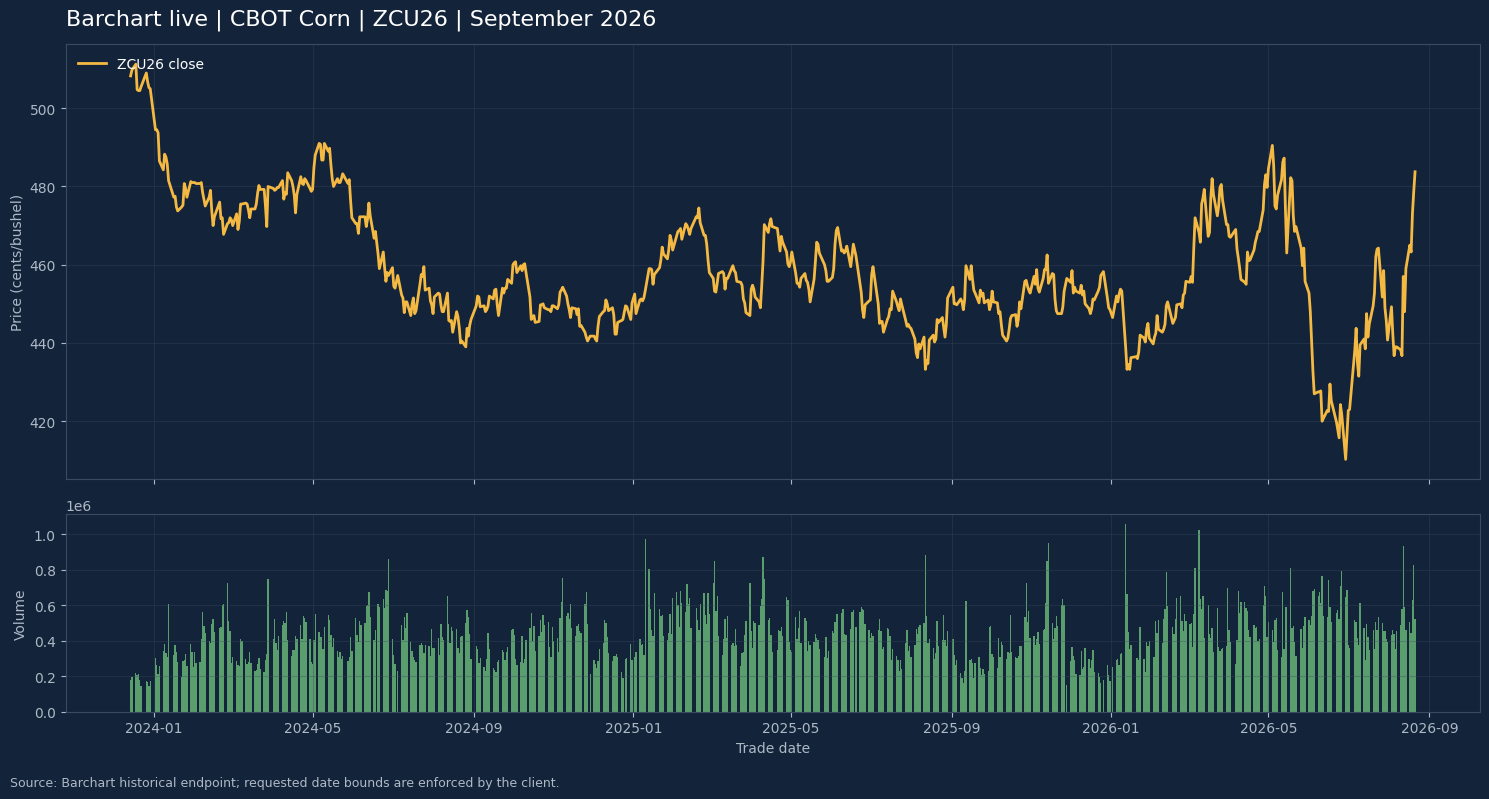

In [7]:
if USE_LIVE_DATA:
    try:
        client = BarchartHistoricalData()
        live_builder = ContinuousFuturesBuilder(
            fetcher=BarchartFetcher(client),
            verbose=True,
        )
        live_series, live_segments = live_builder.build_from_root(
            CORN_ROOT,
            line_number=1,
            start=START,
            end=END,
            months=CORN_CYCLE,
            return_segments=True,
        )
        live_specific_contract = client.history(
            SPECIFIC_CONTRACT,
            start_date="2023-12-01",
            end_date=None,
            out="df",
        )
        if live_specific_contract.empty:
            raise ValueError(f"No Barchart rows returned for {SPECIFIC_CONTRACT}.")

        display(live_segments)
        display(
            pd.DataFrame(
                {
                    "contract": [SPECIFIC_CONTRACT],
                    "contract_month": ["September 2026"],
                    "first_date": [live_specific_contract["date"].min().date()],
                    "last_date": [live_specific_contract["date"].max().date()],
                    "rows": [len(live_specific_contract)],
                    "last_close": [live_specific_contract["close"].iat[-1]],
                    "average_volume": [live_specific_contract["volume"].mean()],
                }
            )
        )
        display(live_specific_contract.tail())

        fig, axes = plt.subplots(
            2,
            1,
            figsize=(15, 8),
            sharex=True,
            gridspec_kw={"height_ratios": [2.2, 1]},
        )
        fig.patch.set_facecolor(navy)
        for axis in axes:
            axis.set_facecolor(navy)
            axis.grid(True, color="#3A4A60", alpha=0.35)
            axis.tick_params(colors=muted)
            for spine in axis.spines.values():
                spine.set_color("#3A4A60")

        axes[0].plot(
            live_specific_contract["date"],
            live_specific_contract["close"],
            color=gold,
            linewidth=2.0,
            label="ZCU26 close",
        )
        axes[0].set_title(
            "Barchart live | CBOT Corn | ZCU26 | September 2026",
            loc="left",
            color="white",
            fontsize=16,
            pad=14,
        )
        axes[0].set_ylabel("Price (cents/bushel)", color=muted)
        axes[0].legend(frameon=False, labelcolor="white", loc="upper left")

        axes[1].bar(
            live_specific_contract["date"],
            live_specific_contract["volume"],
            width=1.0,
            color=field_green,
            alpha=0.85,
        )
        axes[1].set_ylabel("Volume", color=muted)
        axes[1].set_xlabel("Trade date", color=muted)
        fig.text(
            0.01,
            0.01,
            "Source: Barchart historical endpoint; requested date bounds are enforced by the client.",
            color=muted,
            fontsize=9,
        )
        fig.tight_layout(rect=[0, 0.03, 1, 1])
        plt.show()
    except Exception as exc:
        print("Live Barchart data unavailable; showing the offline illustration above.")
        print(f"{type(exc).__name__}: {exc}")
else:
    print("USE_LIVE_DATA is False; showing the offline Corn futures illustration above.")